In [1]:
import torch
import torch.nn as nn
import pandas as pd
from copy import deepcopy as dc
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
print(f"PyTorch built with CUDA Version: {torch.version.cuda}")

PyTorch built with CUDA Version: 12.8


In [3]:
call_centers = ["A", "B", "C", "D"]
types = ["Daily", "Interval"]

dfs = pd.read_excel("data/Data for Datathon (Revised).xlsx", sheet_name=[
    f"{center} - {type}"
    for center in call_centers
    for type in types
])

In [28]:
df = dfs["A - Interval"].dropna() #[["Date", "CCT"]]
# df["Date"] = df["Month"] + df["Day"] + df["Interval"]
df[(df.Month == "April") & (df.Day == 7)]

,Month,Day,Interval,Service Level,Call Volume,Abandoned Calls,Abandoned Rate,CCT
271,April,7,00:00:00,1.0000,5.0,0.0,0.0000,350.40
272,April,7,00:30:00,1.0000,5.0,0.0,0.0000,266.80
273,April,7,01:00:00,1.0000,1.0,0.0,0.0000,286.00
281,April,7,06:30:00,1.0000,1.0,0.0,0.0000,53.00
282,April,7,07:00:00,0.8571,8.0,1.0,0.1250,185.29
283,April,7,07:30:00,1.0000,6.0,0.0,0.0000,540.83
284,April,7,08:00:00,1.0000,33.0,0.0,0.0000,305.48
285,April,7,08:30:00,0.8506,87.0,0.0,0.0000,297.95
286,April,7,09:00:00,0.9292,113.0,0.0,0.0000,319.73
287,April,7,09:30:00,0.9657,176.0,1.0,0.0057,368.04


In [36]:
from datetime import datetime

# for m, d, t, in zip(df["Month"], df["Day"], df["Interval"]):
#     date_str = f"{m} {d} 2025 {t}"
#     print(date_str)
#     print(datetime.strptime(date_str, "%B %d %Y %H:%M:%S"))
df["Date"] = [datetime.strptime(f"{m} {d} 2025 {t}", "%B %d %Y %H:%M:%S") for m, d, t, in zip(df["Month"], df["Day"], df["Interval"])]
df = df[["Date", "CCT"]]

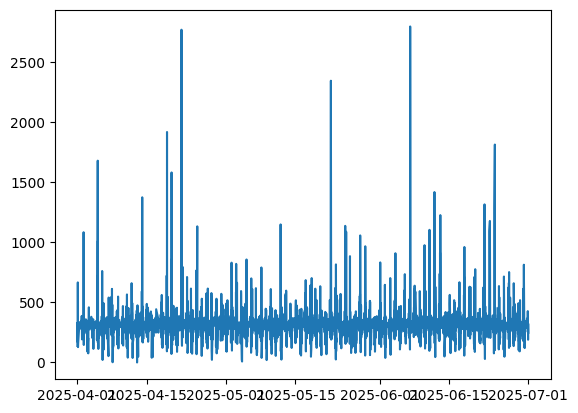

In [37]:
plt.plot(df["Date"], df["CCT"])

In [38]:
def prepare_df_for_lstm(df, n_steps):
    df = dc(df)
    df['Date'] = pd.to_datetime(df['Date'])
    
    df.set_index('Date', inplace=True)
    
    for i in reversed(range(1, n_steps+1)):
        df[f'CCT(t-{i})'] = df['CCT'].shift(i)
    
    df.dropna(inplace=True)
    
    return df

lookback = 7
shifted_df = prepare_df_for_lstm(df, lookback)
shifted_df

,CCT,CCT(t-7),CCT(t-6),CCT(t-5),CCT(t-4),CCT(t-3),CCT(t-2),CCT(t-1)
Date,,,,,,,,
2025-04-01 03:30:00,158.00,137.60,263.40,333.25,170.00,667.00,416.50,128.00
2025-04-01 09:30:00,316.33,263.40,333.25,170.00,667.00,416.50,128.00,158.00
2025-04-01 10:00:00,288.58,333.25,170.00,667.00,416.50,128.00,158.00,316.33
2025-04-01 10:30:00,330.24,170.00,667.00,416.50,128.00,158.00,316.33,288.58
2025-04-01 11:00:00,280.94,667.00,416.50,128.00,158.00,316.33,288.58,330.24
...,...,...,...,...,...,...,...,...
2025-06-30 21:30:00,319.81,291.54,327.58,336.50,338.41,322.21,348.86,427.68
2025-06-30 22:00:00,300.22,327.58,336.50,338.41,322.21,348.86,427.68,319.81
2025-06-30 22:30:00,189.50,336.50,338.41,322.21,348.86,427.68,319.81,300.22


In [39]:
device = 'cuda:0' if torch.cuda.is_available else 'cpu'
device

'cuda:0'

In [40]:
scaler = MinMaxScaler(feature_range=(-1, 1))
normalized_shifted_df = torch.tensor(scaler.fit_transform(shifted_df.to_numpy()), dtype=torch.bfloat16, device=device)

normalized_shifted_df

tensor([[-0.8867, -0.9023, -0.8125,  ..., -0.5234, -0.7031, -0.9102],
        [-0.7734, -0.8125, -0.7617,  ..., -0.7031, -0.9102, -0.8867],
        [-0.7930, -0.7617, -0.8789,  ..., -0.9102, -0.8867, -0.7734],
        ...,
        [-0.8633, -0.7578, -0.7578,  ..., -0.6953, -0.7695, -0.7852],
        [-0.7695, -0.7578, -0.7695,  ..., -0.7695, -0.7852, -0.8633],
        [-0.8242, -0.7695, -0.7500,  ..., -0.7852, -0.8633, -0.7695]],
       device='cuda:0', dtype=torch.bfloat16)

In [41]:
X = normalized_shifted_df[:, 1:]
y = normalized_shifted_df[:, 0]

X.shape, y.shape

(torch.Size([3874, 7]), torch.Size([3874]))

In [42]:
normalized_shifted_df.device

device(type='cuda', index=0)

In [43]:
split_index = int(len(X) * .95)
split_index

3680

In [44]:
# need to add dimensions for LSTM
X_train = X[:split_index].reshape(-1, lookback, 1)
X_test = X[split_index:].reshape(-1, lookback, 1)

y_train = y[:split_index].reshape(-1, 1)
y_test = y[split_index:].reshape(-1, 1)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([3680, 7, 1]),
 torch.Size([194, 7, 1]),
 torch.Size([3680, 1]),
 torch.Size([194, 1]))

In [45]:
from torch.utils.data import Dataset

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, i):
        return self.X[i].to(torch.bfloat16), self.y[i].to(torch.bfloat16)

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

In [46]:
train_dataset, test_dataset

(<__main__.TimeSeriesDataset at 0x7f8715d42210>,
 <__main__.TimeSeriesDataset at 0x7f8715d418e0>)

In [47]:
from torch.utils.data import DataLoader

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [48]:
for _, batch in enumerate(train_loader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)

torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size(

In [49]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_stacked_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_stacked_layers = num_stacked_layers

        self.lstm = nn.LSTM(                    # batched first -> batch as first dimension
            input_size, 
            hidden_size, 
            num_stacked_layers, 
            batch_first=True, 
            dtype=torch.bfloat16
        )  
        
        self.fc = nn.Linear(hidden_size, 1, dtype=torch.bfloat16)     # fc to map hidden size to just 1, final value

    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size, dtype=torch.bfloat16).to(device)
        c0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size, dtype=torch.bfloat16).to(device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = LSTM(1, 4, 1)
model.to(device)
model

LSTM(
  (lstm): LSTM(1, 4, batch_first=True)
  (fc): Linear(in_features=4, out_features=1, bias=True)
)

In [50]:
def train_one_epoch():
    model.train(True)
    print(f'Epoch: {epoch + 1}')
    running_loss = 0.0

    for batch_index, batch in enumerate(train_loader):
        x_batch, y_batch = batch[0], batch[1]

        output = model(x_batch)
        loss = loss_function(output, y_batch)
        running_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_index % 10 == 9:  # print every 100 batches
            avg_loss_across_batches = running_loss / 100
            print('Batch {0}, Loss: {1:.3f}'.format(batch_index+1,
                                                    avg_loss_across_batches))
            running_loss = 0.0
    print()

def validate_one_epoch():
    model.train(False)
    running_loss = 0.0

    for batch_index, batch in enumerate(test_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        with torch.no_grad():
            output = model(x_batch)
            loss = loss_function(output, y_batch)
            running_loss += loss.item()

    avg_loss_across_batches = running_loss / len(test_loader)

    print('Val Loss: {0:.3f}'.format(avg_loss_across_batches))
    print('***************************************************')
    print()

In [51]:
learning_rate = 0.001
num_epochs = 10
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    train_one_epoch()
    validate_one_epoch()

Epoch: 1


/home/ethanc12/jems/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


Batch 10, Loss: 0.002
Batch 20, Loss: 0.002
Batch 30, Loss: 0.002
Batch 40, Loss: 0.001
Batch 50, Loss: 0.001
Batch 60, Loss: 0.001
Batch 70, Loss: 0.002
Batch 80, Loss: 0.001
Batch 90, Loss: 0.004
Batch 100, Loss: 0.001
Batch 110, Loss: 0.001
Batch 120, Loss: 0.001
Batch 130, Loss: 0.001
Batch 140, Loss: 0.001
Batch 150, Loss: 0.001
Batch 160, Loss: 0.001
Batch 170, Loss: 0.001
Batch 180, Loss: 0.001
Batch 190, Loss: 0.001
Batch 200, Loss: 0.000
Batch 210, Loss: 0.000
Batch 220, Loss: 0.001
Batch 230, Loss: 0.000

Val Loss: 0.005
***************************************************

Epoch: 2
Batch 10, Loss: 0.001
Batch 20, Loss: 0.001
Batch 30, Loss: 0.001
Batch 40, Loss: 0.000
Batch 50, Loss: 0.001
Batch 60, Loss: 0.000
Batch 70, Loss: 0.001
Batch 80, Loss: 0.000
Batch 90, Loss: 0.003
Batch 100, Loss: 0.000
Batch 110, Loss: 0.000
Batch 120, Loss: 0.003
Batch 130, Loss: 0.002
Batch 140, Loss: 0.001
Batch 150, Loss: 0.001
Batch 160, Loss: 0.000
Batch 170, Loss: 0.000
Batch 180, Loss: 0.

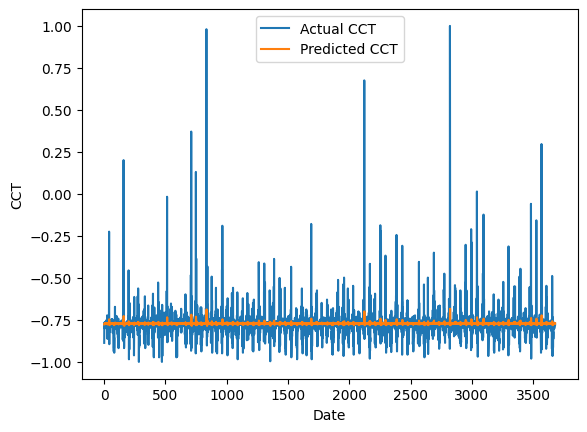

In [53]:
with torch.no_grad():
    predicted = model(X_train).to(torch.float32).cpu().numpy()

plt.plot(y_train.to(torch.float32).cpu().numpy(), label='Actual CCT')
plt.plot(predicted, label='Predicted CCT')
plt.xlabel('Date')
plt.ylabel('CCT')
plt.legend()
plt.show()
